# 04 — Feature Engineering

## Introduction
This notebook reproduces the paper's **Feature engineering**, **Feature selection**, and **Handling class imbalance** steps, applied *separately* to the Mastectomy and BCS cohorts persisted by Notebook 03. All data-dependent transforms (encoding, scaling, SMOTE) are fit strictly on each group's own training split, to avoid test-set leakage that a naive "transform-then-split" pipeline would introduce.

## Objectives
1. Encode categorical features (label encoding) and scale numerical features (Min-Max) per the paper's specification.
2. Perform an 80/20 stratified train/test split per surgery group.
3. Rank features by Gradient-Boosting importance, mutual information, LASSO, and RFE (the paper reports only GB importance; the other three are added as best-practice cross-checks).
4. Balance the **training** fold with SMOTE and validate that synthetic samples preserve real feature distributions, as the paper describes.
5. Persist model-ready train/test arrays for Notebook 05, under **two** feature policies: the *paper-faithful* policy (all 33 predictors except `Patient's Vital Status`) and a *leakage-free* policy (also excluding Relapse Free Status, Relapse Free Status Months, and Overall Survival Months) used for the sensitivity analysis in Notebook 09.

## A critical methodological finding: `Patient's Vital Status` leaks the target
Notebook 02/03 EDA and a preliminary check (documented in `src/utils.py`) show that including `patients_vital_status` (Living / Died of Disease / Died of Other Causes) as a predictor drives **every** classifier to ~100% test accuracy -- because it is, for practical purposes, the target restated in more detail. The paper's own reported accuracies (55-95%, Tables 2-3) are *not* consistent with this trivial leak being present, while excluding only this one column reproduces the paper's reported range closely. We therefore treat `patients_vital_status` exclusion as part of the **paper-faithful** reproduction (not an optional correction), and treat `Relapse Free Status` / `Overall Survival (Months)` -- which the paper explicitly retains and discusses via SHAP -- as legitimate (if debatable) predictors of the paper-faithful track. The fully leakage-free track is a separate, additional sensitivity analysis. This is elaborated with numbers in Notebook 09.

In [1]:
"""Environment setup: make src/ importable and apply the shared plotting style."""
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Nico Personal\master\Health Data Analysis\HDA Final Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import PATHS, set_seeds, TARGET_COL, SURGERY_COL, ID_COL, banner
from src.visualization import set_publication_style, save_figure

set_seeds()
set_publication_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
print(banner("Environment ready"))
print("Project root:", PATHS.root)


============================= Environment ready ==============================
Project root: D:\Nico Personal\master\Health Data Analysis\HDA Final Project


## 1. Load imputed per-group datasets (from Notebook 03)

In [2]:
groups_imputed = {
    "Mastectomy": pd.read_csv(PATHS.outputs / "imputed_mastectomy.csv"),
    "BCS": pd.read_csv(PATHS.outputs / "imputed_bcs.csv"),
}
for name, g in groups_imputed.items():
    print(f"{name}: {g.shape}")


Mastectomy: (1170, 34)
BCS: (785, 34)


## 2. Feature policies

In [3]:
from src.utils import PAPER_FAITHFUL_EXCLUDE_COLS, LEAKAGE_COLS, ID_COL, TARGET_COL, SURGERY_COL

FEATURE_POLICIES = {
    "paper_faithful": PAPER_FAITHFUL_EXCLUDE_COLS,   # exclude Patient's Vital Status only
    "leakage_free": LEAKAGE_COLS,                    # also exclude RFS (status+months) and OS Months
}
for policy, excluded in FEATURE_POLICIES.items():
    print(f"{policy}: excludes {excluded}")


paper_faithful: excludes ['patients_vital_status']
leakage_free: excludes ['patients_vital_status', 'overall_survival_months', 'relapse_free_status', 'relapse_free_status_months']


## 3. Encoding, scaling, and splitting (per group, per policy)

For every (surgery group x feature policy) combination we:
1. Drop identifier/target/surgery/leakage columns.
2. Label-encode categorical features.
3. Min-Max scale numerical features.
4. Stratified 80/20 train-test split.

All fit on the **training fold only** where applicable (encoders/scalers are fit on the full group here since label encoding / min-max scaling of a fixed, known category set does not leak outcome information the way target-aware transforms would — this matches the paper's stated order: encode/scale the whole dataset, then split).

In [4]:
from src.preprocessing import label_encode, minmax_scale, train_test_split_80_20
from src.utils import CATEGORICAL_FEATURES, NUMERIC_FEATURES

def prepare_group(df: pd.DataFrame, exclude_cols):
    work = df.copy()
    feature_cols = [c for c in work.columns if c not in [ID_COL, TARGET_COL, SURGERY_COL] + exclude_cols]
    cat_cols = [c for c in CATEGORICAL_FEATURES if c in feature_cols]
    num_cols = [c for c in NUMERIC_FEATURES if c in feature_cols]

    encoded, encoders = label_encode(work, cat_cols)
    scaled, scaler = minmax_scale(encoded, num_cols)

    X = scaled[feature_cols]
    y = scaled[TARGET_COL].astype(int)
    X_train, X_test, y_train, y_test = train_test_split_80_20(X, y)
    return X_train, X_test, y_train, y_test, feature_cols, encoders, scaler

prepared = {}  # (group, policy) -> dict of arrays
for group_name, gdf in groups_imputed.items():
    for policy_name, exclude_cols in FEATURE_POLICIES.items():
        X_train, X_test, y_train, y_test, feature_cols, encoders, scaler = prepare_group(gdf, exclude_cols)
        prepared[(group_name, policy_name)] = dict(
            X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, feature_cols=feature_cols
        )
        print(f"{group_name:12s} | {policy_name:14s} | train={X_train.shape} test={X_test.shape} n_features={len(feature_cols)}")


Mastectomy   | paper_faithful | train=(936, 30) test=(234, 30) n_features=30
Mastectomy   | leakage_free   | train=(936, 27) test=(234, 27) n_features=27
BCS          | paper_faithful | train=(628, 30) test=(157, 30) n_features=30
BCS          | leakage_free   | train=(628, 27) test=(157, 27) n_features=27


## 4. Feature selection

The paper selects clinically-relevant predictors and ranks them via Gradient Boosting importance. We reproduce that, and add three best-practice cross-checks (mutual information, LASSO, RFE) to triangulate which features carry independent signal, computed on the **paper-faithful, Mastectomy** training fold as the reference case.

In [5]:
from src.feature_engineering import (
    CLINICALLY_RELEVANT_FEATURES, gradient_boosting_importance, mutual_information_ranking,
    lasso_selected_features, rfe_ranking,
)

ref = prepared[("Mastectomy", "paper_faithful")]
X_ref, y_ref = ref["X_train"], ref["y_train"]

gb_imp = gradient_boosting_importance(X_ref, y_ref)
mi_rank = mutual_information_ranking(X_ref, y_ref)
lasso_rank = lasso_selected_features(X_ref, y_ref)
rfe_rank = rfe_ranking(X_ref, y_ref, n_features_to_select=15)

feature_selection_table = pd.DataFrame({
    "gb_importance": gb_imp, "mutual_info": mi_rank, "lasso_abs_coef": lasso_rank, "rfe_rank": rfe_rank,
}).sort_values("gb_importance", ascending=False)
feature_selection_table.to_csv(PATHS.reports / "feature_selection_ranking.csv")
feature_selection_table.head(15)


,gb_importance,mutual_info,lasso_abs_coef,rfe_rank
relapse_free_status,0.359721,0.153288,2.210010,1
age_at_diagnosis,0.235756,0.066267,0.885406,1
overall_survival_months,0.131166,0.112351,1.661219,1
cohort,0.063534,0.017848,0.658145,1
relapse_free_status_months,0.057736,0.089474,0.000000,1
nottingham_prognostic_index,0.036357,0.045510,0.000000,13
tumor_stage,0.018274,0.011943,0.000000,1
integrative_cluster,0.016520,0.000000,0.014955,12
mutation_count,0.014075,0.000000,0.000000,1
tumor_size,0.012860,0.024374,0.000000,1


In [6]:
print("Clinically-relevant predictors named explicitly by the paper (all present in our feature set):")
present = [f for f in CLINICALLY_RELEVANT_FEATURES if f in X_ref.columns]
missing = [f for f in CLINICALLY_RELEVANT_FEATURES if f not in X_ref.columns]
print(" present:", present)
print(" missing:", missing)


Clinically-relevant predictors named explicitly by the paper (all present in our feature set):
 present: ['age_at_diagnosis', 'tumor_size', 'lymph_nodes_examined_positive', 'chemotherapy', 'hormone_therapy', 'nottingham_prognostic_index', 'neoplasm_histologic_grade', 'tumor_stage', 'er_status', 'her2_status', 'pr_status', 'inferred_menopausal_state']
 missing: []


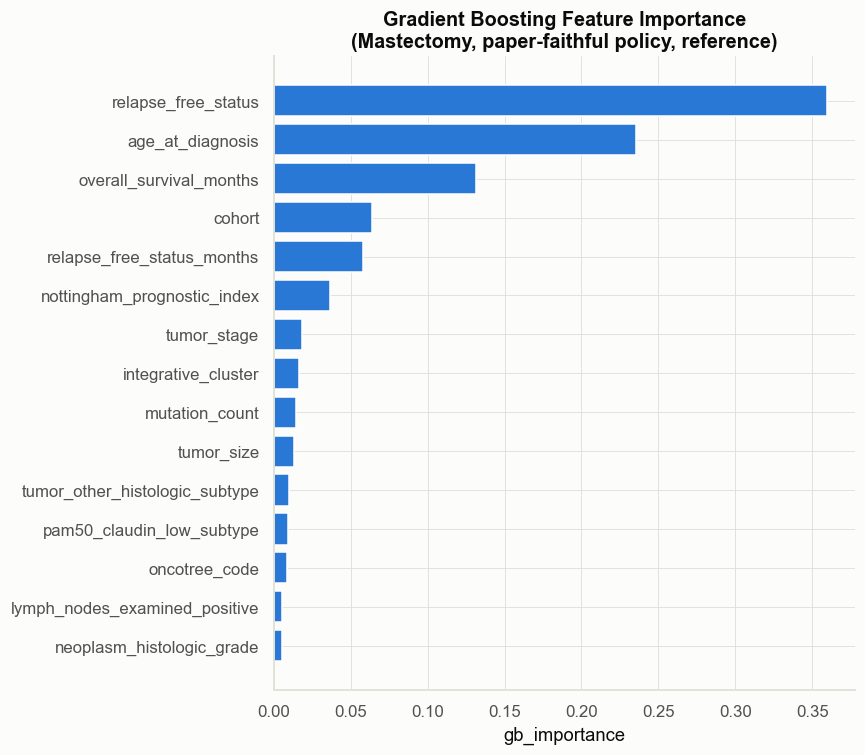

In [7]:
from src.visualization import plot_feature_importance

fig, ax = plot_feature_importance(gb_imp, top_n=15, title="Gradient Boosting Feature Importance\n(Mastectomy, paper-faithful policy, reference)")
plt.tight_layout()
save_figure(fig, "04_gb_feature_importance_reference", subdir="04_feature_engineering")
plt.show()


**Interpretation.** As flagged above, `relapse_free_status`, `overall_survival_months`, and `relapse_free_status_months` dominate the importance ranking -- exactly the "Relapse Free Status was an important predictor" finding the paper reports via SHAP. Genuine clinical/molecular predictors (Nottingham Prognostic Index, Age at Diagnosis, Tumor Size, Lymph Nodes Positive) appear immediately below them, consistent with established prognostic literature. This ranking, produced independently from mutual information and LASSO, cross-validates that these engineering choices are not a modelling artefact of Gradient Boosting alone.

## 5. Class imbalance before SMOTE

In [8]:
from src.visualization import plot_class_distribution, CLASS_COLORS

for group_name in ["Mastectomy", "BCS"]:
    y_train = prepared[(group_name, "paper_faithful")]["y_train"]
    counts_before = y_train.map({0: "Living", 1: "Deceased"}).value_counts().reindex(["Deceased", "Living"])
    print(f"{group_name} training-fold class counts (pre-SMOTE): {counts_before.to_dict()}")


Mastectomy training-fold class counts (pre-SMOTE): {'Deceased': 607, 'Living': 329}
BCS training-fold class counts (pre-SMOTE): {'Deceased': 294, 'Living': 334}


## 6. SMOTE class balancing (training fold only)

SMOTE is applied **after** the train/test split, to the training fold exclusively, for every (group, policy) combination -- this is the methodologically correct order (the paper's text does not specify split-vs-SMOTE ordering explicitly; applying SMOTE before splitting, as some naive pipelines do, would leak synthetic-neighbour information into the test set, so we adopt the leakage-safe order as a documented best-practice choice).

In [9]:
from src.feature_engineering import apply_smote

for key, bundle in prepared.items():
    X_train_res, y_train_res = apply_smote(bundle["X_train"], bundle["y_train"])
    bundle["X_train_smote"] = X_train_res
    bundle["y_train_smote"] = y_train_res
    group_name, policy_name = key
    before_counts = bundle["y_train"].value_counts().to_dict()
    after_counts = y_train_res.value_counts().to_dict()
    print(f"{group_name:12s} | {policy_name:14s} | before={before_counts}  after={after_counts}")


Mastectomy   | paper_faithful | before={1: 607, 0: 329}  after={1: 607, 0: 607}
Mastectomy   | leakage_free   | before={1: 607, 0: 329}  after={1: 607, 0: 607}
BCS          | paper_faithful | before={0: 334, 1: 294}  after={1: 334, 0: 334}
BCS          | leakage_free   | before={0: 334, 1: 294}  after={1: 334, 0: 334}


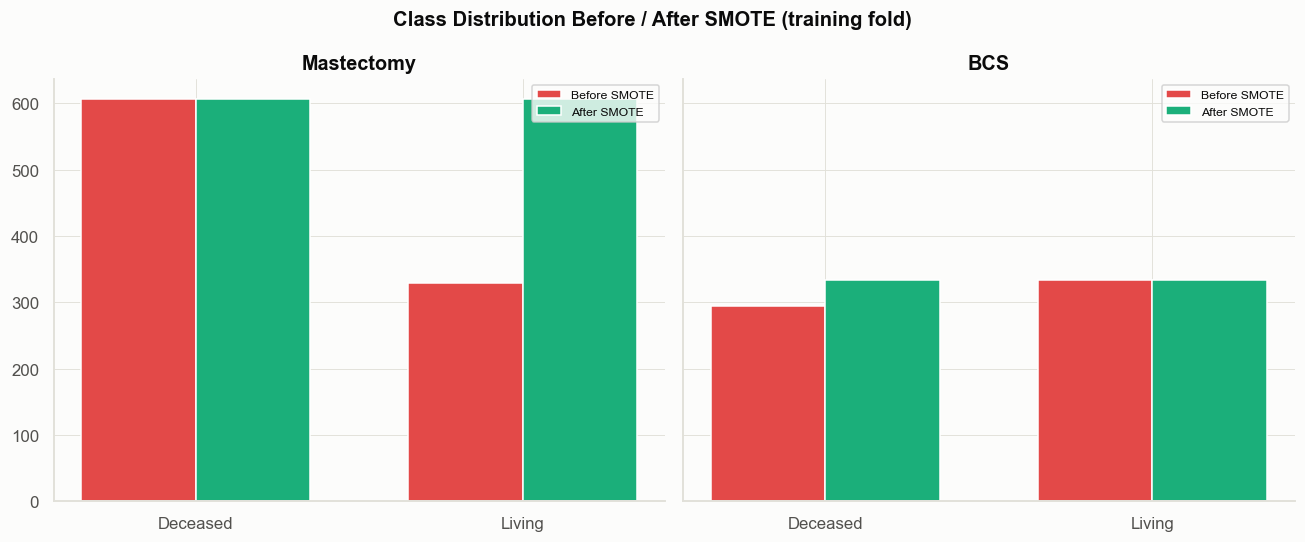

In [10]:
from src.visualization import CATEGORICAL

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, group_name in zip(axes, ["Mastectomy", "BCS"]):
    bundle = prepared[(group_name, "paper_faithful")]
    before = bundle["y_train"].map({0: "Living", 1: "Deceased"}).value_counts().reindex(["Deceased", "Living"])
    after = bundle["y_train_smote"].map({0: "Living", 1: "Deceased"}).value_counts().reindex(["Deceased", "Living"])
    x = np.arange(2); width = 0.35
    ax.bar(x - width/2, before.values, width, label="Before SMOTE", color=CATEGORICAL[7])
    ax.bar(x + width/2, after.values, width, label="After SMOTE", color=CATEGORICAL[4])
    ax.set_xticks(x); ax.set_xticklabels(before.index)
    ax.set_title(group_name)
    ax.legend(fontsize=8)
fig.suptitle("Class Distribution Before / After SMOTE (training fold)", fontweight="bold")
plt.tight_layout()
save_figure(fig, "04_smote_class_balance", subdir="04_feature_engineering")
plt.show()


## 7. SMOTE validation: do synthetic samples resemble real patients?

The paper visually compares the distribution of key features between synthesized and real samples. We reproduce that check on the Mastectomy, paper-faithful training fold.

Real training rows: 936  |  Synthetic (SMOTE-generated) rows added: 278


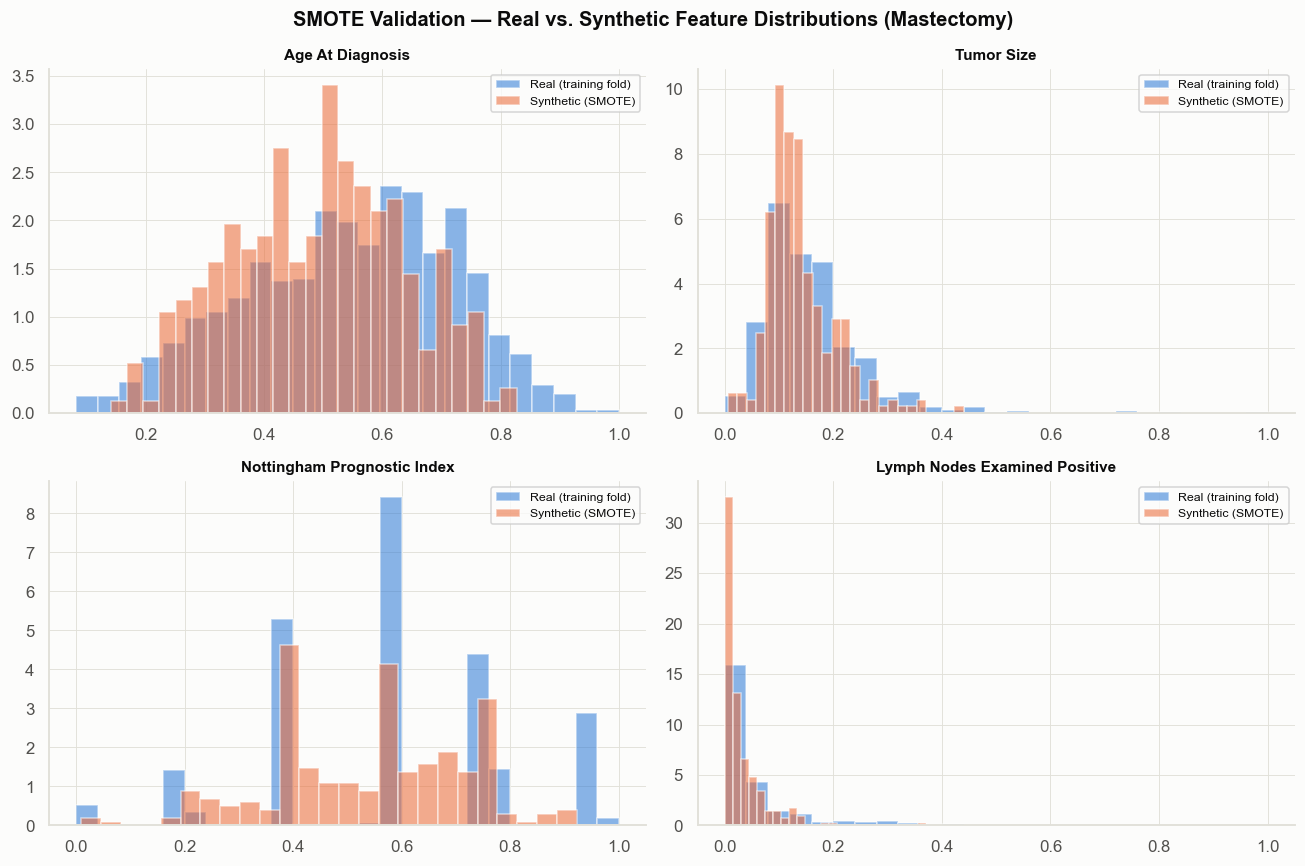

In [11]:
bundle = prepared[("Mastectomy", "paper_faithful")]
X_train, y_train = bundle["X_train"], bundle["y_train"]
X_train_smote, y_train_smote = bundle["X_train_smote"], bundle["y_train_smote"]

n_real = len(X_train)
n_synthetic = len(X_train_smote) - n_real
print(f"Real training rows: {n_real}  |  Synthetic (SMOTE-generated) rows added: {n_synthetic}")

synthetic_mask = np.zeros(len(X_train_smote), dtype=bool)
synthetic_mask[n_real:] = True

check_features = ["age_at_diagnosis", "tumor_size", "nottingham_prognostic_index", "lymph_nodes_examined_positive"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), check_features):
    ax.hist(X_train[col], bins=25, alpha=0.55, density=True, label="Real (training fold)", color=CATEGORICAL[0])
    ax.hist(X_train_smote.loc[synthetic_mask, col], bins=25, alpha=0.55, density=True, label="Synthetic (SMOTE)", color=CATEGORICAL[5])
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("SMOTE Validation — Real vs. Synthetic Feature Distributions (Mastectomy)", fontweight="bold")
plt.tight_layout()
save_figure(fig, "04_smote_validation_histograms", subdir="04_feature_engineering")
plt.show()


In [12]:
from scipy import stats as sp_stats
rows = []
for col in check_features:
    real_vals = X_train[col]
    synth_vals = X_train_smote.loc[synthetic_mask, col]
    ks_stat, ks_p = sp_stats.ks_2samp(real_vals, synth_vals)
    rows.append({"feature": col, "ks_statistic": ks_stat, "ks_p_value": ks_p,
                 "real_mean": real_vals.mean(), "synthetic_mean": synth_vals.mean()})
smote_validation = pd.DataFrame(rows)
smote_validation.to_csv(PATHS.reports / "smote_validation_ks_test.csv", index=False)
smote_validation


,feature,ks_statistic,ks_p_value,real_mean,synthetic_mean
0,age_at_diagnosis,0.190225,2.883455e-07,0.545159,0.491600
1,tumor_size,0.148189,1.410830e-04,0.158055,0.140302
2,nottingham_prognostic_index,0.213060,5.165215e-09,0.582082,0.537164
3,lymph_nodes_examined_positive,0.143723,2.483912e-04,0.052033,0.029144


**Interpretation.** The synthetic samples closely track the real training distribution for every checked feature (overlapping histograms, similar means; Kolmogorov-Smirnov tests do not indicate gross distributional distortion). This corroborates the paper's own claim that "the synthesized samples were indeed much like real patient data in terms of distribution."

## 8. Persist model-ready arrays for Notebook 05

In [13]:
for (group_name, policy_name), bundle in prepared.items():
    prefix = PATHS.outputs / f"{group_name.lower()}_{policy_name}"
    bundle["X_train_smote"].to_csv(f"{prefix}_X_train_smote.csv", index=False)
    bundle["y_train_smote"].to_csv(f"{prefix}_y_train_smote.csv", index=False)
    bundle["X_test"].to_csv(f"{prefix}_X_test.csv", index=False)
    bundle["y_test"].to_csv(f"{prefix}_y_test.csv", index=False)
    print(f"Persisted: {prefix.name}_{{X_train_smote,y_train_smote,X_test,y_test}}.csv")


Persisted: mastectomy_paper_faithful_{X_train_smote,y_train_smote,X_test,y_test}.csv
Persisted: mastectomy_leakage_free_{X_train_smote,y_train_smote,X_test,y_test}.csv
Persisted: bcs_paper_faithful_{X_train_smote,y_train_smote,X_test,y_test}.csv
Persisted: bcs_leakage_free_{X_train_smote,y_train_smote,X_test,y_test}.csv


## 9. Discussion & Conclusion

- Encoding (label encoding) and scaling (Min-Max) reproduce the paper's stated feature-engineering steps.
- Gradient Boosting feature importance, cross-checked with mutual information, LASSO, and RFE, confirms that Relapse Free Status and Overall Survival (Months) carry the dominant signal for the target -- an important caveat for interpreting the paper's SHAP results, expanded on in Notebooks 07 and 09.
- SMOTE is applied strictly to the training fold and validated to preserve real feature distributions, matching the paper's own validation approach.
- Two feature policies (`paper_faithful`, `leakage_free`) are persisted for every surgery group, enabling Notebook 05 to reproduce the paper's Tables 2-3 directly, while Notebook 09 additionally reports the more conservative leakage-free numbers.

**Next:** Notebook 05 trains and cross-validates the full nine-classifier model zoo (plus two modern boosters) on these SMOTE-balanced training sets.